# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [15]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create connection to database
conn = sqlite3.connect('data.sqlite')


### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [16]:
# California customers with a high credit limit
query2 = """
SELECT
    customerNumber,
    customerName,
    city,
    state,
    CAST(creditLimit AS REAL) AS creditLimit
FROM customers
WHERE state = 'CA'
  AND CAST(creditLimit AS REAL) > 25000
ORDER BY creditLimit DESC;
"""

california_high_credit = pd.read_sql(query2, conn)
california_high_credit


,customerNumber,customerName,city,state,creditLimit
0,124,Mini Gifts Distributors Ltd.,San Rafael,CA,210500.0
1,239,Collectable Mini Designs Co.,San Diego,CA,105000.0
2,321,Corporate Gift Ideas Co.,San Francisco,CA,105000.0
3,205,Toys4GrownUps.com,Pasadena,CA,90700.0
4,161,Technics Stores Inc.,Burlingame,CA,84600.0
5,450,The Sharp Gifts Warehouse,San Jose,CA,77600.0
6,129,Mini Wheels Co.,San Francisco,CA,64600.0
7,487,Signal Collectibles Ltd.,Brisbane,CA,60300.0
8,347,"Men 'R' US Retailers, Ltd.",Los Angeles,CA,57700.0
9,475,West Coast Collectables Co.,Burbank,CA,55400.0


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [17]:
# International customers whose names contain "Collect"
query3 = """
SELECT
    customerNumber,
    customerName,
    country
FROM customers
WHERE country <> 'USA'
  AND customerName LIKE '%Collect%'
ORDER BY customerName;
"""

international_collectors = pd.read_sql(query3, conn)
international_collectors


,customerNumber,customerName,country
0,471,"Australian Collectables, Ltd",Australia
1,114,"Australian Collectors, Co.",Australia
2,293,BG&E Collectables,Switzerland
3,415,"Bavarian Collectables Imports, Co.",Germany
4,189,"Clover Collections, Co.",Ireland
5,227,Heintze Collectables,Denmark
6,211,"King Kong Collectables, Co.",Hong Kong
7,480,"Kremlin Collectables, Co.",Russia
8,376,Precious Collectables,Switzerland
9,353,Reims Collectables,France


## Reflection Question

The `WHERE` clause applies two filters at the same time. First, `country <> 'USA'` removes customers located in the United States, so the result only contains international customers. Second, `customerName LIKE '%Collect%'` looks for the word fragment **Collect** anywhere inside the customer name. The percent signs act as wildcards, meaning other text can appear before or after that fragment. Because the two conditions are connected with `AND`, a customer must satisfy **both** requirements to appear in the result.


### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [18]:
# Average credit limit by U.S. state
query4 = """
SELECT
    state,
    ROUND(AVG(CAST(creditLimit AS REAL)), 2) AS avg_credit_limit,
    COUNT(*) AS customer_count
FROM customers
WHERE country = 'USA'
  AND state IS NOT NULL
  AND creditLimit IS NOT NULL
GROUP BY state
ORDER BY avg_credit_limit DESC;
"""

state_credit = pd.read_sql(query4, conn)
state_credit


,state,avg_credit_limit,customer_count
0,NH,114200.00,1
1,NY,89966.67,6
2,PA,84766.67,3
3,CA,83854.55,11
4,NV,71800.00,1
5,MA,70755.56,9
6,CT,57350.00,4
7,NJ,43000.00,1


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

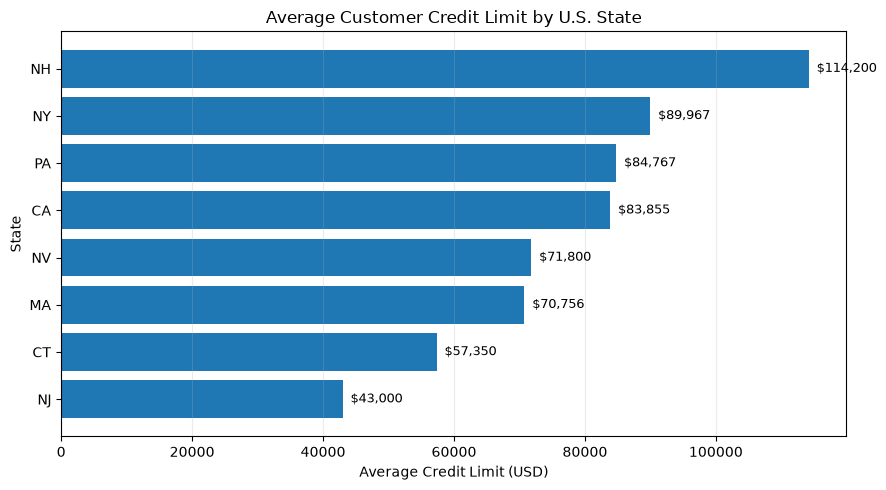

In [19]:
# Visual: average credit limit by state
plot_df = state_credit.sort_values('avg_credit_limit')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_df['state'], plot_df['avg_credit_limit'])
ax.set_title('Average Customer Credit Limit by U.S. State')
ax.set_xlabel('Average Credit Limit (USD)')
ax.set_ylabel('State')
ax.grid(axis='x', alpha=0.25)

for bar, value in zip(bars, plot_df['avg_credit_limit']):
    ax.text(value + 1200, bar.get_y() + bar.get_height()/2,
            f'${value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [20]:
# Top 10 customers by total payments
query5 = """
SELECT
    c.customerNumber,
    c.customerName,
    ROUND(SUM(p.amount), 2) AS total_payments
FROM customers AS c
JOIN payments AS p
  ON c.customerNumber = p.customerNumber
GROUP BY c.customerNumber, c.customerName
ORDER BY total_payments DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query5, conn)
top_customers


,customerNumber,customerName,total_payments
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

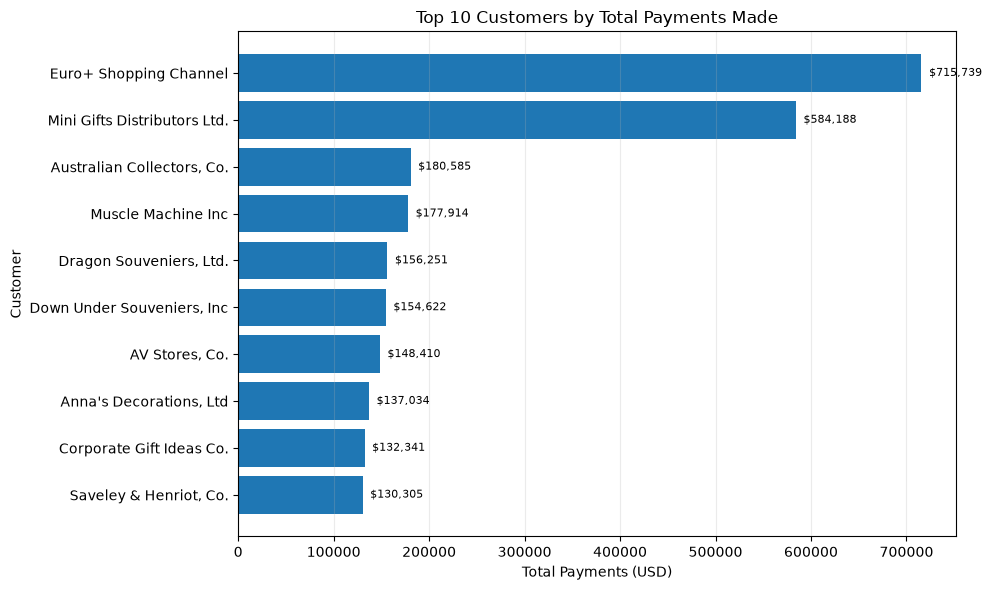

In [21]:
# Visual: top ten customers by total payments
plot_df = top_customers.sort_values('total_payments')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df['customerName'], plot_df['total_payments'])
ax.set_title('Top 10 Customers by Total Payments Made')
ax.set_xlabel('Total Payments (USD)')
ax.set_ylabel('Customer')
ax.grid(axis='x', alpha=0.25)

for bar, value in zip(bars, plot_df['total_payments']):
    ax.text(value + 8000, bar.get_y() + bar.get_height()/2,
            f'${value:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [22]:
# Products each customer purchased in a total quantity of 10 or more
query6 = """
SELECT
    c.customerNumber,
    c.customerName,
    p.productCode,
    p.productName,
    SUM(od.quantityOrdered) AS total_quantity_purchased
FROM customers AS c
JOIN orders AS o
  ON c.customerNumber = o.customerNumber
JOIN orderdetails AS od
  ON o.orderNumber = od.orderNumber
JOIN products AS p
  ON od.productCode = p.productCode
GROUP BY c.customerNumber, c.customerName, p.productCode, p.productName
HAVING SUM(od.quantityOrdered) >= 10
ORDER BY total_quantity_purchased ASC;
"""

customer_product_quantities = pd.read_sql(query6, conn)
customer_product_quantities


,customerNumber,customerName,productCode,productName,total_quantity_purchased
0,314,Petit Auto,S18_2949,1913 Ford Model T Speedster,10
1,412,"Extreme Desk Decorations, Ltd",S24_4620,1961 Chevrolet Impala,10
2,119,La Rochelle Gifts,S32_2509,1954 Greyhound Scenicruiser,11
3,328,Tekni Collectables Inc.,S700_1691,American Airlines: B767-300,11
4,450,The Sharp Gifts Warehouse,S24_3191,1969 Chevrolet Camaro Z28,13
...,...,...,...,...,...
2526,141,Euro+ Shopping Channel,S24_3432,2002 Chevy Corvette,174
2527,141,Euro+ Shopping Channel,S12_4473,1957 Chevy Pickup,183
2528,141,Euro+ Shopping Channel,S24_1444,1970 Dodge Coronet,197
2529,141,Euro+ Shopping Channel,S24_2840,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [23]:
# Product-line demand and assortment size
query7 = """
SELECT
    p.productLine,
    COUNT(DISTINCT p.productCode) AS number_of_products,
    SUM(od.quantityOrdered) AS total_quantity_ordered
FROM products AS p
JOIN orderdetails AS od
  ON p.productCode = od.productCode
GROUP BY p.productLine
ORDER BY total_quantity_ordered DESC;
"""

product_line_analysis = pd.read_sql(query7, conn)
product_line_analysis


,productLine,number_of_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

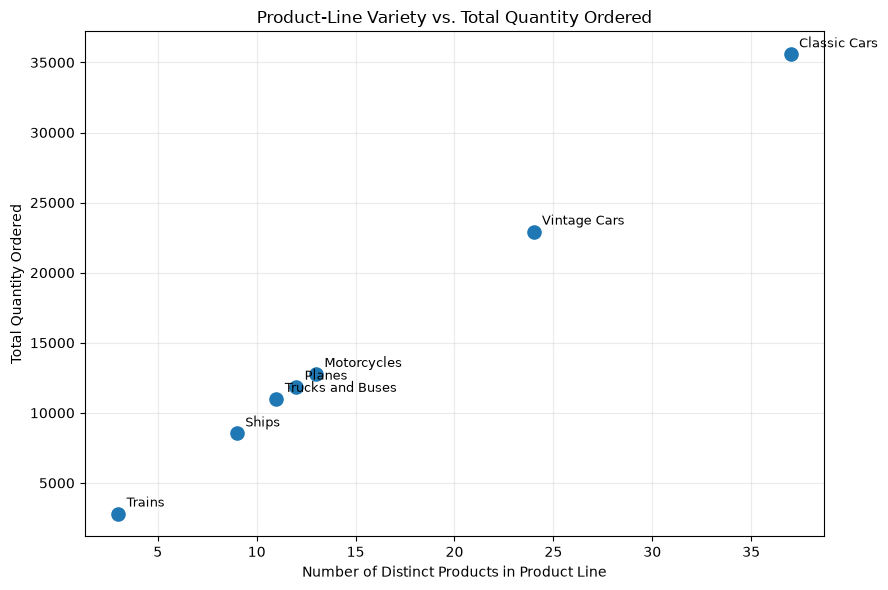

In [24]:
# Visual: relationship between assortment size and quantity ordered
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    product_line_analysis['number_of_products'],
    product_line_analysis['total_quantity_ordered'],
    s=90
)

for _, row in product_line_analysis.iterrows():
    ax.annotate(
        row['productLine'],
        (row['number_of_products'], row['total_quantity_ordered']),
        xytext=(6, 5),
        textcoords='offset points',
        fontsize=9
    )

ax.set_title('Product-Line Variety vs. Total Quantity Ordered')
ax.set_xlabel('Number of Distinct Products in Product Line')
ax.set_ylabel('Total Quantity Ordered')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Reflection Question

I used a **scatter plot** because the question asks whether two numerical measurements appear to move together: the number of distinct products in a product line and the total quantity ordered. Each point represents one product line, so it is easy to see both measurements at once and compare the overall pattern.

The visual suggests that product lines with more distinct products generally also have higher total order quantities. For example, Classic Cars has both the largest assortment and the highest quantity ordered, while Trains has the smallest assortment and the lowest quantity ordered. This is only a preliminary relationship and does not prove that adding products causes more orders, but it gives the product team a useful pattern to investigate further.


### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [25]:
# Employees in offices with fewer than five employees
query8 = """
SELECT
    e.employeeNumber,
    e.firstName,
    e.lastName,
    e.email,
    e.officeCode,
    e.jobTitle,
    e.reportsTo,
    s.firstName || ' ' || s.lastName AS supervisor_name
FROM employees AS e
LEFT JOIN employees AS s
  ON e.reportsTo = s.employeeNumber
WHERE e.officeCode IN (
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(*) < 5
)
ORDER BY e.officeCode, e.lastName;
"""

remote_office_employees = pd.read_sql(query8, conn)
remote_office_employees


,employeeNumber,firstName,lastName,email,officeCode,jobTitle,reportsTo,supervisor_name
0,1188,Julie,Firrelli,jfirrelli@classicmodelcars.com,2,Sales Rep,1143,Anthony Bow
1,1216,Steve,Patterson,spatterson@classicmodelcars.com,2,Sales Rep,1143,Anthony Bow
2,1286,Foon Yue,Tseng,ftseng@classicmodelcars.com,3,Sales Rep,1143,Anthony Bow
3,1323,George,Vanauf,gvanauf@classicmodelcars.com,3,Sales Rep,1143,Anthony Bow
4,1625,Yoshimi,Kato,ykato@classicmodelcars.com,5,Sales Rep,1621,Mami Nishi
5,1621,Mami,Nishi,mnishi@classicmodelcars.com,5,Sales Rep,1056,Mary Patterson
6,1611,Andy,Fixter,afixter@classicmodelcars.com,6,Sales Rep,1088,William Patterson
7,1619,Tom,King,tking@classicmodelcars.com,6,Sales Rep,1088,William Patterson
8,1612,Peter,Marsh,pmarsh@classicmodelcars.com,6,Sales Rep,1088,William Patterson
9,1088,William,Patterson,wpatterson@classicmodelcars.com,6,Sales Manager (APAC),1056,Mary Patterson


## Reflection Question

I first needed to identify which offices meet management's definition of a small office. The subquery groups the `employees` table by `officeCode` and uses `HAVING COUNT(*) < 5` to return only office codes with fewer than five employees.

The main query then uses those returned office codes inside `WHERE e.officeCode IN (...)`. This means the employee details are only returned when that employee belongs to one of the small offices. I also self-joined the employees table so the result includes each employee's supervisor name in addition to the `reportsTo` ID.


### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [26]:
# Close the Part 1 database connection
conn.close()


### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [27]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

,total_movies,missing_genres,missing_runtime,earliest_year,latest_year
0,145081,5359,30765,2010,2019


,movie_id,primary_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0100275,The Wandering Soap Opera,2017,80.0,"Comedy,Drama,Fantasy",6.5,119
4,tt0137204,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy",8.1,263


Movies available for complete-case exploration: 65,720


,genre,movie_count,average_rating,median_votes,total_votes
8,Drama,28394,6.39,85.0,119452909
7,Documentary,16423,7.32,21.0,4709902
5,Comedy,15514,6.01,118.0,74181319
23,Thriller,7583,5.59,165.0,48126681
13,Horror,6917,4.93,103.0,23857774
0,Action,6297,5.78,242.0,101126583
19,Romance,5976,6.15,149.0,26875313
6,Crime,4338,6.11,204.0,39618088
4,Biography,3693,7.17,41.0,21603178
2,Adventure,3621,6.18,131.0,84222953


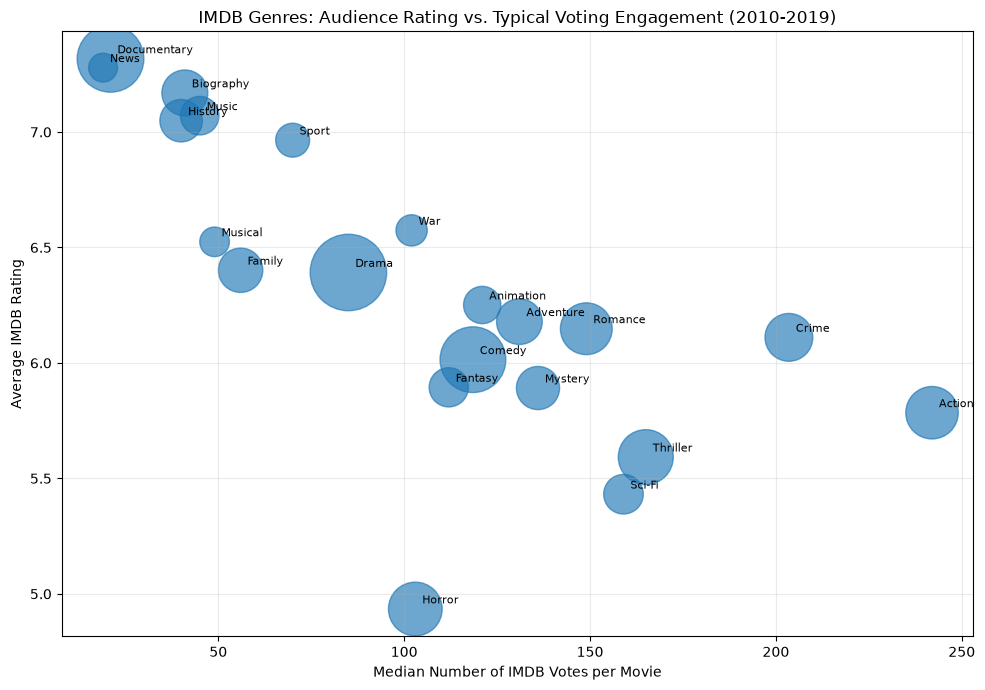

,runtime_minutes
count,65720.000000
mean,94.732273
std,209.377017
min,3.000000
50%,91.000000
90%,120.000000
95%,135.000000
99%,161.000000
max,51420.000000


,start_year,rated_movies,average_rating
0,2010,6792,6.26
1,2011,7389,6.29
2,2012,7680,6.30
3,2013,7990,6.29
4,2014,8371,6.32
5,2015,8494,6.27
6,2016,8721,6.35
7,2017,8713,6.40
8,2018,7526,6.42
9,2019,2180,6.70


In [28]:
# Part 2: Exploratory analysis of IMDB movie data (2010-2019)

# 1) Broad data-quality and scope check
movie_scope = pd.read_sql("""
SELECT
    COUNT(*) AS total_movies,
    SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) AS missing_genres,
    SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) AS missing_runtime,
    MIN(start_year) AS earliest_year,
    MAX(start_year) AS latest_year
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019;
""", conn4)
display(movie_scope)

# 2) Pull complete fields needed for the exploration.
movie_analysis = pd.read_sql("""
SELECT
    mb.movie_id,
    mb.primary_title,
    mb.start_year,
    mb.runtime_minutes,
    mb.genres,
    mr.averagerating,
    mr.numvotes
FROM movie_basics AS mb
JOIN movie_ratings AS mr
  ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mb.genres IS NOT NULL
  AND mb.runtime_minutes IS NOT NULL
  AND mr.averagerating IS NOT NULL
  AND mr.numvotes IS NOT NULL;
""", conn4)
display(movie_analysis.head())
print(f"Movies available for complete-case exploration: {len(movie_analysis):,}")

# 3) Normalize the comma-separated genre field for exploratory comparisons.
genre_movies = (
    movie_analysis
    .assign(genre=movie_analysis['genres'].str.split(','))
    .explode('genre')
)

genre_summary = (
    genre_movies
    .groupby('genre')
    .agg(
        movie_count=('movie_id', 'nunique'),
        average_rating=('averagerating', 'mean'),
        median_votes=('numvotes', 'median'),
        total_votes=('numvotes', 'sum')
    )
    .reset_index()
)

genre_focus = (
    genre_summary[genre_summary['movie_count'] >= 500]
    .sort_values('movie_count', ascending=False)
)
display(genre_focus.round({'average_rating': 2, 'median_votes': 0}))

# 4) Visualization supporting the business question.
fig, ax = plt.subplots(figsize=(10, 7))
sizes = np.sqrt(genre_focus['movie_count']) * 18
ax.scatter(
    genre_focus['median_votes'],
    genre_focus['average_rating'],
    s=sizes,
    alpha=0.65
)
for _, row in genre_focus.iterrows():
    ax.annotate(
        row['genre'],
        (row['median_votes'], row['average_rating']),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8
    )
ax.set_title('IMDB Genres: Audience Rating vs. Typical Voting Engagement (2010-2019)')
ax.set_xlabel('Median Number of IMDB Votes per Movie')
ax.set_ylabel('Average IMDB Rating')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Runtime sanity check for potential cleaning needs.
runtime_check = movie_analysis['runtime_minutes'].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)
display(runtime_check.to_frame('runtime_minutes'))

# 6) Year-level coverage check.
year_summary = pd.read_sql("""
SELECT
    mb.start_year,
    COUNT(*) AS rated_movies,
    ROUND(AVG(mr.averagerating), 2) AS average_rating
FROM movie_basics AS mb
JOIN movie_ratings AS mr
  ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mr.averagerating IS NOT NULL
GROUP BY mb.start_year
ORDER BY mb.start_year;
""", conn4)
display(year_summary)

conn4.close()


## Part 2 Findings and Interpretation

### Initial exploration findings
- The complete-case analysis contains **65,720 rated movies** released from 2010 through 2019 after excluding null genres, runtimes, ratings, and vote counts.
- **Drama** is the largest genre in the analyzed data, followed by Documentary and Comedy.
- Genre performance is not one-dimensional. **Documentary** has a high average rating but relatively low typical voting engagement, while **Action** attracts substantially more voting activity but has a lower average rating.
- The vote distribution is highly skewed, so the visualization uses **median votes** rather than mean votes to represent a more typical movie within each genre.
- Runtime contains extreme values, including values far beyond a normal feature-film length, which should be investigated before using runtime in deeper analysis.
- The number of rated movies varies by year, and 2019 has noticeably fewer records in this dataset than most earlier years, so year-to-year comparisons require caution.

### Business question for further analysis
**Which established movie genres offer the strongest combination of audience satisfaction (IMDB rating) and audience engagement (vote activity), and does that relationship remain consistent across release years from 2010 through 2019?**

This question follows directly from the genre comparison: some genres score highly on ratings while others generate much more audience voting activity. A studio, distributor, or content investor could use deeper analysis of that tradeoff to help evaluate which genres appear to combine positive reception with broad audience interest.

### Potential data-cleaning tasks
- Exclude null values in the fields required for each analysis rather than imputing them.
- Normalize the comma-separated `genres` field into one genre per row before genre-level analysis.
- Investigate and set defensible rules for unrealistic or extreme `runtime_minutes` values before using runtime analytically.
- Account for the highly skewed `numvotes` distribution; median values or transformations may be more informative than simple averages.
- Check for duplicate movie/person relationships after joins to tables such as `principals`, `directors`, and `writers`.
- Standardize categorical text fields such as genre, region, language, and profession before grouping.
- Treat 2019 carefully because this database has lower observed rated-movie coverage for that year than most preceding years in the analysis window.
